In [1]:
import pandas as pd
import numpy as np
import math
import random
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

MODELS_CACHE = {}

def main(year, sim_count):
    
    data = pd.read_csv("../../data/data_official.csv")
    
    if year not in MODELS_CACHE:
        try:
            with open(f'../RFmodels/rf_model_{year}.pkl', 'rb') as f:
                MODELS_CACHE[year] = pickle.load(f)
        except FileNotFoundError:
            raise ValueError(f"Model for year {year} not found. Please train it first.")
            
    model = MODELS_CACHE[year]
    
    data['Sim_Wins'] = [-1 for _ in range(len(data))]
    data['R68_win%'] = [1.0 for _ in range(len(data))]
    data['R64_win%'] = [0.0 for _ in range(len(data))]
    data['R32_win%'] = [0.0 for _ in range(len(data))]
    data['S16_win%'] = [0.0 for _ in range(len(data))]
    data['E8_win%'] = [0.0 for _ in range(len(data))]
    data['F4_win%'] = [0.0 for _ in range(len(data))]
    data['CG_win%'] = [0.0 for _ in range(len(data))]
    data['R68_opp'] = ["N/A" for _ in range(len(data))]
    data['R64_opp'] = ["N/A" for _ in range(len(data))]
    data['R32_opp'] = ["N/A" for _ in range(len(data))]
    data['S16_opp'] = ["N/A" for _ in range(len(data))]
    data['E8_opp'] = ["N/A" for _ in range(len(data))]
    data['F4_opp'] = ["N/A" for _ in range(len(data))]
    data['CG_opp'] = ["N/A" for _ in range(len(data))]
    
    i = 0
    
    sims = []
    scores = []
        
    while i < sim_count:
        
        sim_df = simulation(year, i, data, model)
        
        score = 0

        score = score + (10 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 0) & (sim_df["Sim_Wins"] > 0)])))
        score = score + (20 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 1) & (sim_df["Sim_Wins"] > 1)])))
        score = score + (40 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 2) & (sim_df["Sim_Wins"] > 2)])))
        score = score + (80 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 3) & (sim_df["Sim_Wins"] > 3)])))
        score = score + (160 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 4) & (sim_df["Sim_Wins"] > 4)])))
        score = score + (320 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 5) & (sim_df["Sim_Wins"] > 5)])))
        
        sims.append(sim_df)
        scores.append(score)
        i = i+1
                
    full_df = pd.concat(sims, axis=0).reset_index(drop=True)
    
    final_df = calc_outcome(full_df)
    
    final_df1 = final_df[['sim_num', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp', 'Outcome_%']]
        
    return final_df1, scores

def simulation(year, sim_num, data, model):
    
    data = data.copy()
    
    data['sim_num'] = sim_num + 1
    
    df1 = region_simulation(data, year, 1, model)
    df1n = df1[df1["QUAD ID"] == 1]
    df2 = region_simulation(data, year, 2, model)
    df2n = df2[df2["QUAD ID"] == 2]
    df3 = region_simulation(data, year, 3, model)
    df3n = df3[df3["QUAD ID"] == 3]
    df4 = region_simulation(data, year, 4, model)
    df4n = df4[df4["QUAD ID"] == 4]
    
    df = pd.concat([df1n, df2n, df3n, df4n])
        
    df = final4(df, year, model)
    
    df = championship(df, year, model)
    
    df_year = df[df["YEAR"] == year]
    dfn = df_year[['sim_num', 'YEAR', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp']]
                            
    return dfn

def region_simulation(data, year, quad, model):
    
    seeds = list(range(1,17))

    ###########################################################################
    # FIRST FOUR
    
    for seed in seeds:
    
        if data[(data["SEED"] == seed) & (data["YEAR"] == year) & (data["QUAD ID"] == quad)].shape[0] > 1:
            
            data = same_seed(data, year, quad, seed, model)
    ##########################################################################
    ##########################################################################
    # FIRST ROUND (R64)
        
    data = round64(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SECOND ROUND (R32)
    
    data = round32(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SWEET 16
    
    data = sweet16(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # ELITE 8
    
    data = elite8(data, year, quad, model)
    
    return data

def same_seed(data, year, quad, seed, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["SEED"] == seed)].copy()
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    
    data.loc[team0index, "R68_win%"] = perc
    data.loc[team1index, "R68_win%"] = 1-perc
    data.loc[team0index, "R68_opp"] = team1name
    data.loc[team1index, "R68_opp"] = team0name
    
    winner = weighted_coin_flip(perc)

    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 0

    else:
        data.loc[team0index, "Sim_Wins"] = 0
        
    return data

def round64(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    seeds1 = [1,2,3,4,5,6,7,8]
    seeds2 = [16,15,14,13,12,11,10,9]
    
    for i in range(0,8):
        
        rdf = subdf[(subdf["SEED"] == seeds1[i]) | (subdf["SEED"] == seeds2[i])]
        team0 = rdf.head(1)
        team0name = str(team0["TEAM"].iloc[0])
        team0index = team0["TEAM"].index
        team1 = rdf.tail(1)
        team1name = str(team1["TEAM"].iloc[0])
        team1index = team1["TEAM"].index
                
        perc = find_percentages(data, team0name, team1name, year, model)
        
        data.loc[team0index, "R64_win%"] = perc
        data.loc[team1index, "R64_win%"] = 1-perc
        data.loc[team0index, "R64_opp"] = team1name
        data.loc[team1index, "R64_opp"] = team0name

        winner = weighted_coin_flip(perc)
        
        if winner == 1:
            data.loc[team1index, "Sim_Wins"] = 0

        else:
            data.loc[team0index, "Sim_Wins"] = 0

    return data

def round32(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[(subdf["SEED"] == 1) | (subdf["SEED"] == 16)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 8) | (subdf["SEED"] == 9)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 5) | (subdf["SEED"] == 12)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 4) | (subdf["SEED"] == 13)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 6) | (subdf["SEED"] == 11)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 3) | (subdf["SEED"] == 14)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 7) | (subdf["SEED"] == 10)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 2) | (subdf["SEED"] == 15)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
        
    return data

def sweet16(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,8,9,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options2 = [4,5,12,13]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2

    options3 = [3,6,11,14]
    for i in options3:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options4 = [2,7,10,15]
    for i in options4:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2  
    
    return data

def elite8(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,4,5,8,9,12,13,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    
    options2 = [2,3,6,7,10,11,14,15]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "E8_win%"] = perc
    data.loc[team1index, "E8_win%"] = 1-perc
    data.loc[team0index, "E8_opp"] = team1name
    data.loc[team1index, "E8_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 3
    else:
        data.loc[team0index, "Sim_Wins"] = 3
        
    return data

def final4(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[subdf["QUAD ID"] == 1]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 2]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4
        
    team0 = subdf[subdf["QUAD ID"] == 3]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 4]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
        
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4    
    
    return data

def championship(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "CG_win%"] = perc
    data.loc[team1index, "CG_win%"] = 1-perc
    data.loc[team0index, "CG_opp"] = team1name
    data.loc[team1index, "CG_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 5
        data.loc[team0index, "Sim_Wins"] = 6
    else:
        data.loc[team0index, "Sim_Wins"] = 5
        data.loc[team1index, "Sim_Wins"] = 6    
    
    return data

def game_style(df, team0, team1, year):
    
    cols = ['KADJ T',
       'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%',
       'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', '3PT%D', 'AST%',
       '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 'EXP', 'FT%',
       'ELITE SOS']
    
    t0 = df[(df["TEAM"] == team0) & (df["YEAR"] == year)].reset_index(drop=True)
    t1 = df[(df["TEAM"] == team1) & (df["YEAR"] == year)].reset_index(drop=True)
    
    game = pd.DataFrame()
    
    for col in cols:
        game[col] = t0[col] - t1[col]
    game.insert(0, "YEAR", year)
    game.insert(1, "Team0", t0["TEAM"])
    game.insert(2, "Team1", t1["TEAM"])
    
    return game

def find_percentages(df, team0, team1, year, model):
    
    features = ['KADJ T', 'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 
                'TOV%', 'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', 
                '3PT%D', 'AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 
                'EXP', 'FT%', 'ELITE SOS']
    
    game_01 = game_style(df, team0, team1, year)
    game_10 = game_style(df, team1, team0, year)
    
    X_test_01 = game_01[features].values
    X_test_10 = game_10[features].values
    
    probs_01 = model.predict_proba(X_test_01)[0]
    probs_10 = model.predict_proba(X_test_10)[0]
    
    team0_win_prob = (probs_01[0] + probs_10[1]) / 2
    team1_win_prob = (probs_01[1] + probs_10[0]) / 2
    
    return team0_win_prob

def weighted_coin_flip(perc1):
    
    num = random.random()
    
    if num < perc1:
        return 1
    
    else:
        return 2
    
def calc_outcome(df):
    
    df['Outcome_%'] = [0 for _ in range(len(df))]
    
    df.loc[df['Sim_Wins'] == 6, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * df['CG_win%']
    df.loc[df['Sim_Wins'] == 5, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * (1-df['CG_win%'])
    df.loc[df['Sim_Wins'] == 4, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * (1-df['F4_win%'])
    df.loc[df['Sim_Wins'] == 3, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * (1-df['E8_win%'])
    df.loc[df['Sim_Wins'] == 2, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * (1-df['S16_win%'])
    df.loc[df['Sim_Wins'] == 1, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * (1-df['R32_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] != 0), 'Outcome_%'] = df['R68_win%'] * (1-df['R64_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] == 0), 'Outcome_%'] = (1-df['R68_win%'])
    
    df['R68_win%'] = df['R68_win%'].mul(100).round(3)
    df['R64_win%'] = df['R64_win%'].mul(100).round(3)
    df['R32_win%'] = df['R32_win%'].mul(100).round(3)
    df['S16_win%'] = df['S16_win%'].mul(100).round(3)
    df['E8_win%'] = df['E8_win%'].mul(100).round(3)
    df['F4_win%'] = df['F4_win%'].mul(100).round(3)
    df['CG_win%'] = df['CG_win%'].mul(100).round(3)
    df['Outcome_%'] = df['Outcome_%'].mul(100).round(3)
        
    return df

In [2]:
df, scores = main(2018, 10000)

In [3]:
import numpy as np

top_5_indices = np.argsort(scores)[-5:][::-1]  
top_5 = [(i+1, scores[i]) for i in top_5_indices] 

bottom_5_indices = np.argsort(scores)[:5]  
bottom_5 = [(i+1, scores[i]) for i in bottom_5_indices]

avg_score = np.mean(scores)

print("=" * 40)
print("TOP 5 SCORES")
print("=" * 40)
for sim_num, score in top_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print("BOTTOM 5 SCORES")
print("=" * 40)
for sim_num, score in bottom_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print(f"AVERAGE SCORE: {avg_score:.2f}")
print("=" * 40)

TOP 5 SCORES
Sim #7524: 1520
Sim #142: 1480
Sim #7246: 1470
Sim #9168: 1460
Sim #666: 1460

BOTTOM 5 SCORES
Sim #5327: 200
Sim #4455: 200
Sim #1173: 200
Sim #934: 210
Sim #6921: 210

AVERAGE SCORE: 557.30


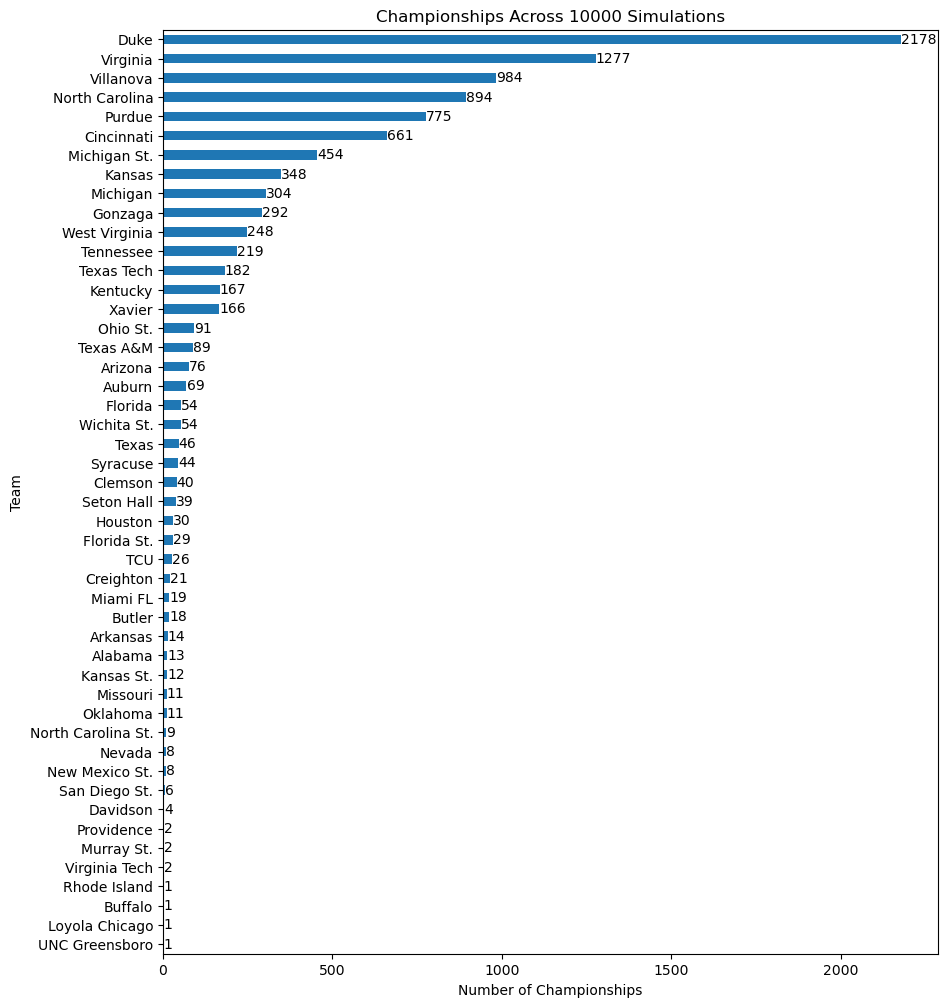

In [4]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] == 6, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Championships Across 10000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Championships")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [5]:
from itertools import zip_longest
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] == 6)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Championships by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Championships by Team for 10000 Simulations

Duke              2178 --> 21.78%          Clemson            40 --> 0.4%             UNC Greensboro      1 --> 0.01%         
Virginia          1277 --> 12.77%          Seton Hall         39 --> 0.39%            Buffalo             1 --> 0.01%         
Villanova         984 --> 9.84%            Houston            30 --> 0.3%             St. Bonaventure     0 --> 0.0%          
North Carolina    894 --> 8.94%            Florida St.        29 --> 0.29%            South Dakota St.    0 --> 0.0%          
Purdue            775 --> 7.75%            TCU                26 --> 0.26%            College of Charleston   0 --> 0.0%      
Cincinnati        661 --> 6.61%            Creighton          21 --> 0.21%            Marshall            0 --> 0.0%          
Michigan St.      454 --> 4.54%            Miami FL           19 --> 0.19%            Bucknell            0 --> 0.0%          
Kansas            348 --> 3.48%            Butler             18 -

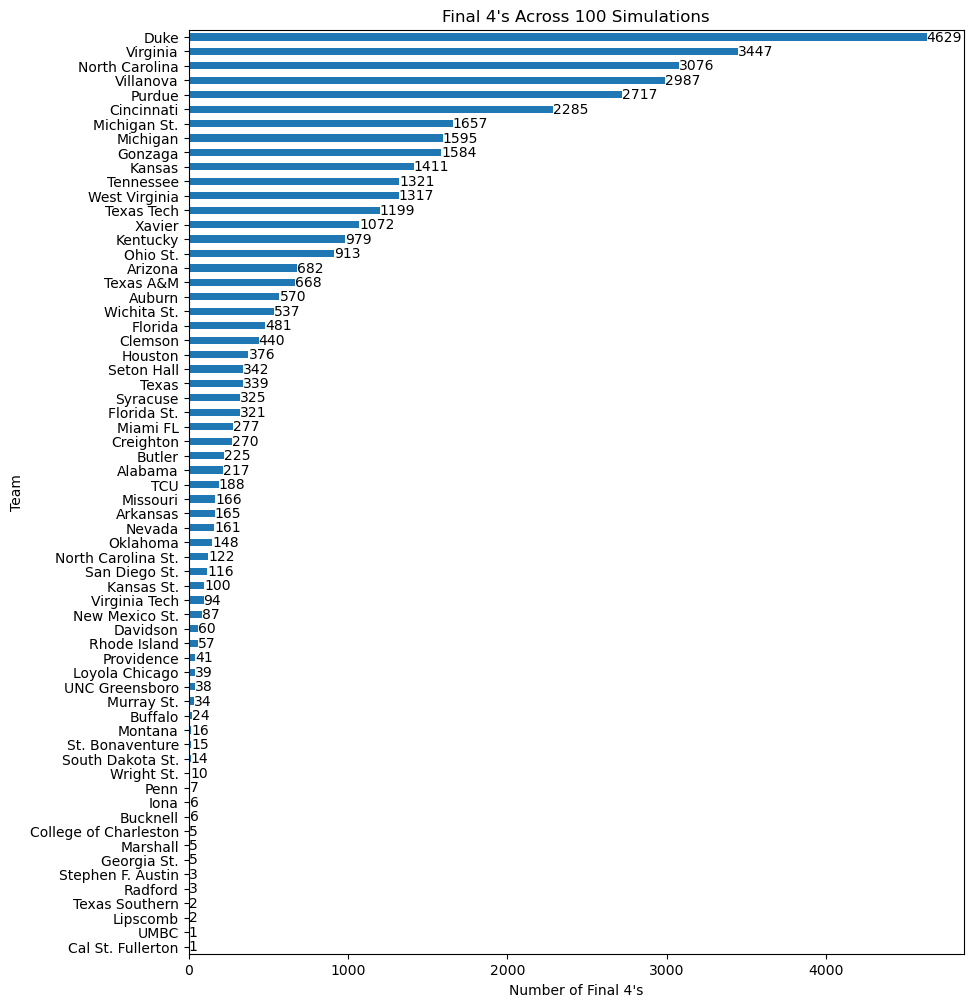

In [6]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] >= 4, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Final 4's Across 100 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Final 4's")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [7]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 4)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Final 4's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Final 4's by Team for 10000 Simulations

Duke              4629 --> 46.29%          Seton Hall        342 --> 3.42%            Murray St.         34 --> 0.34%         
Virginia          3447 --> 34.47%          Texas             339 --> 3.39%            Buffalo            24 --> 0.24%         
North Carolina    3076 --> 30.76%          Syracuse          325 --> 3.25%            Montana            16 --> 0.16%         
Villanova         2987 --> 29.87%          Florida St.       321 --> 3.21%            St. Bonaventure    15 --> 0.15%         
Purdue            2717 --> 27.17%          Miami FL          277 --> 2.77%            South Dakota St.   14 --> 0.14%         
Cincinnati        2285 --> 22.85%          Creighton         270 --> 2.7%             Wright St.         10 --> 0.1%          
Michigan St.      1657 --> 16.57%          Butler            225 --> 2.25%            Penn                7 --> 0.07%         
Michigan          1595 --> 15.95%          Alabama           217 --> 2

In [8]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 3)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Elite 8's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Elite 8's by Team for 10000 Simulations

Duke              5716 --> 57.16%          Florida St.       1047 --> 10.47%          Murray St.        154 --> 1.54%         
Purdue            4946 --> 49.46%          Texas             1003 --> 10.03%          Buffalo           112 --> 1.12%         
Virginia          4923 --> 49.23%          Miami FL          918 --> 9.18%            Montana            88 --> 0.88%         
Villanova         4738 --> 47.38%          Houston           823 --> 8.23%            St. Bonaventure    82 --> 0.82%         
Cincinnati        4379 --> 43.79%          Alabama           683 --> 6.83%            South Dakota St.   71 --> 0.71%         
North Carolina    4299 --> 42.99%          Creighton         681 --> 6.81%            Marshall           53 --> 0.53%         
Kansas            3993 --> 39.93%          Butler            674 --> 6.74%            Georgia St.        50 --> 0.5%          
Gonzaga           3286 --> 32.86%          Syracuse          657 --> 6

In [9]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 2)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Sweet 16's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Sweet 16's by Team for 10000 Simulations

Duke              7820 --> 78.2%           Miami FL          2533 --> 25.33%          UNC Greensboro    610 --> 6.1%          
Virginia          7206 --> 72.06%          Seton Hall        2521 --> 25.21%          Buffalo           529 --> 5.29%         
Purdue            7046 --> 70.46%          Houston           2501 --> 25.01%          St. Bonaventure   524 --> 5.24%         
Villanova         6784 --> 67.84%          Syracuse          2212 --> 22.12%          Montana           484 --> 4.84%         
North Carolina    6443 --> 64.43%          Texas             2172 --> 21.72%          South Dakota St.  361 --> 3.61%         
Tennessee         6370 --> 63.7%           Alabama           1988 --> 19.88%          Marshall          361 --> 3.61%         
Cincinnati        6286 --> 62.86%          TCU               1647 --> 16.47%          Georgia St.       315 --> 3.15%         
Kansas            5941 --> 59.41%          Missouri          1640 -->

In [10]:
pd.set_option('display.max_columns', None)
df.sort_values("Outcome_%", ascending=True).head(25)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
265989,4157,1,Iona,15,0,5,100.0,N/A,8.483,Duke,19.600,Rhode Island,11.388,TCU,8.092,Kansas,13.846,Texas Tech,14.049,Texas A&M,0.002
108801,1701,1,Bucknell,14,0,5,100.0,N/A,12.333,Michigan St.,21.977,Syracuse,8.513,Duke,11.964,Kansas,9.955,Purdue,13.417,North Carolina,0.002
61365,959,4,Georgia St.,15,0,5,100.0,N/A,12.701,Cincinnati,18.374,Texas,13.682,Tennessee,13.486,Kentucky,11.776,Ohio St.,14.349,Auburn,0.004
144342,2256,2,Murray St.,12,0,6,100.0,N/A,18.655,West Virginia,72.452,Marshall,14.756,Villanova,20.994,Texas Tech,9.026,Duke,14.255,Gonzaga,0.005
63962,1000,2,Stephen F. Austin,14,0,5,100.0,N/A,11.980,Texas Tech,16.344,Florida,13.557,Purdue,15.498,Villanova,20.104,North Carolina St.,12.224,Virginia,0.007
210485,3289,4,Georgia St.,15,0,5,100.0,N/A,12.701,Cincinnati,24.784,Nevada,13.682,Tennessee,17.421,Arizona,11.548,North Carolina,10.858,Purdue,0.008
227971,3563,1,College of Charleston,13,0,5,100.0,N/A,15.183,Auburn,23.546,New Mexico St.,13.428,Seton Hall,19.011,Oklahoma,11.062,Villanova,11.934,Ohio St.,0.009
172259,2692,3,Lipscomb,15,0,4,100.0,N/A,10.874,North Carolina,9.128,Texas A&M,11.347,San Diego St.,9.784,Gonzaga,10.562,Tennessee,0.000,N/A,0.010
295877,4624,1,Iona,15,0,4,100.0,N/A,8.483,Duke,15.547,Oklahoma,11.174,Michigan St.,8.092,Kansas,8.751,Villanova,0.000,N/A,0.011
183755,2872,1,Penn,16,0,5,100.0,N/A,10.452,Kansas,18.415,North Carolina St.,18.768,Auburn,20.785,TCU,16.334,West Virginia,9.146,Virginia,0.011


In [11]:
df[df["sim_num"] == 7524].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
481500,7524,2,Villanova,1,6,6,100.0,N/A,89.684,Radford,68.676,Alabama,64.233,West Virginia,70.183,Florida,65.881,Kansas,59.257,Michigan,10.840
481508,7524,3,Michigan,3,5,5,100.0,N/A,83.538,Montana,66.159,Houston,58.383,Texas A&M,56.737,Xavier,56.007,Tennessee,40.743,Villanova,6.076
481531,7524,4,Tennessee,3,1,4,100.0,N/A,85.974,Wright St.,71.113,Miami FL,33.827,Cincinnati,74.331,Kansas St.,43.993,Michigan,0.000,N/A,8.610
481478,7524,1,Kansas,1,4,4,100.0,N/A,89.548,Penn,61.529,Seton Hall,66.975,Clemson,22.576,Duke,34.119,Villanova,0.000,N/A,5.488
481519,7524,3,Xavier,1,1,3,100.0,N/A,88.824,Texas Southern,68.019,Missouri,48.286,Ohio St.,43.263,Michigan,0.000,N/A,0.000,N/A,16.552
481476,7524,1,Duke,2,3,3,100.0,N/A,91.517,Iona,86.768,Rhode Island,77.212,Syracuse,77.424,Kansas,0.000,N/A,0.000,N/A,13.842
481526,7524,4,Kansas St.,9,3,3,100.0,N/A,44.930,Creighton,18.040,Virginia,31.284,Kentucky,25.669,Tennessee,0.000,N/A,0.000,N/A,1.885
481492,7524,2,Florida,6,1,3,100.0,N/A,78.415,St. Bonaventure,37.285,Texas Tech,56.306,Arkansas,29.817,Villanova,0.000,N/A,0.000,N/A,11.554
481527,7524,4,Kentucky,5,2,2,100.0,N/A,74.076,Davidson,59.210,Arizona,68.716,Kansas St.,0.000,N/A,0.000,N/A,0.000,N/A,13.721
481486,7524,1,Syracuse,11,2,2,100.0,N/A,58.721,TCU,78.023,Bucknell,22.788,Duke,0.000,N/A,0.000,N/A,0.000,N/A,35.375


In [12]:
correct = df[df["Wins"] >=5] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 5).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Championship Games: ", len(filtered_df["sim_num"].unique()))

Number of Correct Championship Games:  114


In [13]:
correct = df[df["Wins"] >=4] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 4).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Final 4's: ", len(filtered_df["sim_num"].unique()))
#print(filtered_df["sim_num"].unique())

Number of Correct Final 4's:  0


In [15]:
correct = df[df["Wins"] >=3] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 3).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Elite 8's: ", len(filtered_df["sim_num"].unique()))
#print(filtered_df["sim_num"].unique())

Number of Correct Elite 8's:  0


In [16]:
correct = df[df["Wins"] >=2] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 2).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Sweet 16's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Sweet 16's:  0


In [17]:
correct = df[df["Wins"] >=1] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 1).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Round of 32's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Round of 32's:  0


In [21]:
df[(df["TEAM"] == "Florida St.") & (df["R32_opp"] == "Xavier") & (df["S16_opp"] == "Gonzaga") & (df["E8_opp"] == "Michigan")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
1376,22,3,Florida St.,9,3,4,100.0,N/A,57.824,Missouri,44.156,Xavier,30.54,Gonzaga,36.475,Michigan,42.546,Tennessee,0.000,N/A,1.634
8736,137,3,Florida St.,9,3,4,100.0,N/A,57.824,Missouri,44.156,Xavier,30.54,Gonzaga,36.475,Michigan,29.845,Cincinnati,0.000,N/A,1.995
10080,158,3,Florida St.,9,3,3,100.0,N/A,57.824,Missouri,44.156,Xavier,30.54,Gonzaga,36.475,Michigan,0.000,N/A,0.000,N/A,4.954
16992,266,3,Florida St.,9,3,5,100.0,N/A,57.824,Missouri,44.156,Xavier,30.54,Gonzaga,36.475,Michigan,28.297,Virginia,14.426,Duke,0.689
17184,269,3,Florida St.,9,3,3,100.0,N/A,57.824,Missouri,44.156,Xavier,30.54,Gonzaga,36.475,Michigan,0.000,N/A,0.000,N/A,4.954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589984,9219,3,Florida St.,9,3,5,100.0,N/A,57.824,Missouri,44.156,Xavier,30.54,Gonzaga,36.475,Michigan,65.088,Davidson,14.426,Duke,1.584
590240,9223,3,Florida St.,9,3,3,100.0,N/A,57.824,Missouri,44.156,Xavier,30.54,Gonzaga,36.475,Michigan,0.000,N/A,0.000,N/A,4.954
606496,9477,3,Florida St.,9,3,4,100.0,N/A,57.824,Missouri,44.156,Xavier,30.54,Gonzaga,36.475,Michigan,28.297,Virginia,0.000,N/A,2.039
628192,9816,3,Florida St.,9,3,3,100.0,N/A,57.824,Missouri,44.156,Xavier,30.54,Gonzaga,36.475,Michigan,0.000,N/A,0.000,N/A,4.954


In [22]:
df[df["sim_num"] == 6741].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
431393,6741,3,Gonzaga,4,2,6,100.0,N/A,78.957,UNC Greensboro,62.629,Ohio St.,58.799,Xavier,63.724,Houston,67.357,Arizona,23.144,Duke,2.888
431364,6741,1,Duke,2,3,5,100.0,N/A,91.517,Iona,85.385,Oklahoma,67.447,Michigan St.,77.424,Kansas,79.644,Texas Tech,76.856,Gonzaga,7.522
431387,6741,2,Texas Tech,3,3,4,100.0,N/A,88.020,Stephen F. Austin,82.690,St. Bonaventure,67.478,Butler,79.006,Murray St.,20.356,Duke,0.000,N/A,30.904
431408,6741,4,Arizona,4,0,4,100.0,N/A,77.660,Buffalo,40.790,Kentucky,33.319,Virginia,56.926,Texas,32.643,Gonzaga,0.000,N/A,4.047
431382,6741,2,Murray St.,12,0,3,100.0,N/A,18.655,West Virginia,72.452,Marshall,81.397,Radford,20.994,Texas Tech,0.000,N/A,0.000,N/A,8.692
431394,6741,3,Houston,6,1,3,100.0,N/A,63.659,San Diego St.,33.841,Michigan,45.349,Texas A&M,36.276,Gonzaga,0.000,N/A,0.000,N/A,6.225
431366,6741,1,Kansas,1,4,3,100.0,N/A,89.548,Penn,61.529,Seton Hall,66.975,Clemson,22.576,Duke,0.000,N/A,0.000,N/A,28.571
431420,6741,4,Texas,10,0,3,100.0,N/A,64.539,Nevada,27.071,Cincinnati,39.062,Tennessee,43.074,Arizona,0.000,N/A,0.000,N/A,3.885
431384,6741,2,Radford,16,0,2,100.0,N/A,10.316,Villanova,19.086,Alabama,18.603,Murray St.,0.000,N/A,0.000,N/A,0.000,N/A,1.603
431378,6741,2,Butler,10,1,2,100.0,N/A,53.238,Arkansas,24.400,Purdue,32.522,Texas Tech,0.000,N/A,0.000,N/A,0.000,N/A,8.766


In [24]:
df[(df["TEAM"] == "Villanova") & (df["F4_opp"] == "Duke")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
28,1,2,Villanova,1,6,6,100.0,N/A,89.684,Radford,68.676,Alabama,74.844,Wichita St.,62.175,Texas Tech,43.621,Duke,55.945,North Carolina,6.994
668,11,2,Villanova,1,6,6,100.0,N/A,89.684,Radford,83.471,Virginia Tech,74.844,Wichita St.,58.897,Purdue,43.621,Duke,44.328,Virginia,6.381
1500,24,2,Villanova,1,6,4,100.0,N/A,89.684,Radford,83.471,Virginia Tech,64.233,West Virginia,58.897,Purdue,43.621,Duke,0.000,N/A,15.967
1820,29,2,Villanova,1,6,6,100.0,N/A,89.684,Radford,83.471,Virginia Tech,64.233,West Virginia,62.175,Texas Tech,43.621,Duke,59.257,Michigan,7.728
3612,57,2,Villanova,1,6,4,100.0,N/A,89.684,Radford,68.676,Alabama,89.872,Marshall,58.897,Purdue,43.621,Duke,0.000,N/A,18.380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638364,9975,2,Villanova,1,6,4,100.0,N/A,89.684,Radford,83.471,Virginia Tech,74.844,Wichita St.,58.897,Purdue,43.621,Duke,0.000,N/A,18.605
638620,9979,2,Villanova,1,6,4,100.0,N/A,89.684,Radford,83.471,Virginia Tech,74.844,Wichita St.,58.897,Purdue,43.621,Duke,0.000,N/A,18.605
639196,9988,2,Villanova,1,6,4,100.0,N/A,89.684,Radford,83.471,Virginia Tech,89.872,Marshall,58.897,Purdue,43.621,Duke,0.000,N/A,22.340
639516,9993,2,Villanova,1,6,5,100.0,N/A,89.684,Radford,68.676,Alabama,64.233,West Virginia,70.183,Florida,43.621,Duke,68.227,Gonzaga,3.848


In [18]:
df.to_csv("../../data/2018_10000sims0.csv")